In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import timm
import matplotlib.pyplot as plt
from utils import do_2D_pca
from PIL import Image
from utils import load_image, resize_crop, to_norm_tensor, closest_crop
# DINOv2
#dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to("cuda")
#dinov2_vits14.eval()

from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)

vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=True, device="cuda")

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
black_dog = load_image("images/black_dog.jpg", resize_crop((224,224), (224,224)))[0]
micro_struct = load_image("images/default_image.jpg", resize_crop((224,224), (224,224)))[0]

In [22]:
dog_out =  vit_wrapper.forward_features(black_dog, make_2D=True).detach().squeeze().cpu()
micro_out =  vit_wrapper.forward_features(micro_struct, make_2D=True).detach().squeeze().cpu()

In [23]:
dog_out[[47, 113, 117, 359], ...] = 0
micro_out[[47, 113, 117, 359], ...] = 0

In [24]:
torch.save(dog_out, "black_dog_target.pt")
torch.save(micro_out, "micro_struct_target.pt")

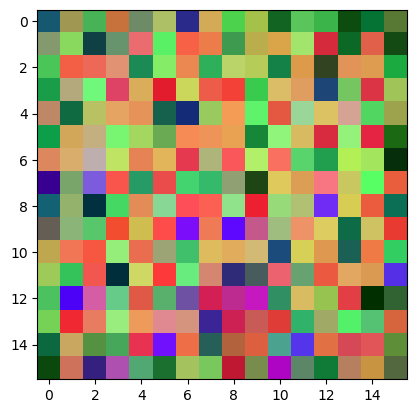

In [20]:
plt.imshow(do_2D_pca(micro_out, post_norm="minmax"))